# Build Freight Timetable

Genereert een synthetische vrachtverkeer-timetable voor de Brusselse corridor.

**Volgorde:**
1. Laad gold passenger timetable
2. Valideer lookups (lijncode + rijtijd per sectie)
3. Genereer freight timetable
4. Valideer output
5. Sla op als gold

**Tijdsconventie:** identiek aan passenger pipeline.  
`PLANNED_ENTRY <= PLANNED_EXIT` altijd.  
`ENTRY_SECONDS`/`EXIT_SECONDS` worden pas toegevoegd in `combine_timetable.py` na samenvoeging met passenger.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s", force=True)

from data.timetable import load_gold, save_gold, add_period
from data.freight import (
    TRAJECTEN,
    DEFAULT_PERIOD_PROBS,
    build_line_no_lookup,
    build_running_time_lookup,
    normalize_to_base_date,
    generate_freight_timetable,
    add_freight_dynamics
)

## 1. Laad gold passenger timetable

In [2]:
passenger = load_gold('passenger')
print(f"Passenger: {passenger['TRAIN_NO'].nunique()} treinen, {len(passenger)} segmenten")
print(f"Kolommen: {passenger.columns.tolist()}")

INFO Gold geladen (passenger): 1028 treinen, 10072 segmenten


Passenger: 1028 treinen, 10072 segmenten
Kolommen: ['SECTION', 'SOURCE', 'TARGET', 'PLANNED_ENTRY', 'PLANNED_EXIT', 'RELATION_DIRECTION', 'TRAIN_NO', 'TYPE', 'TRAIN_TYPE', 'PERIOD', 'DYNAMICS']


## 2. Valideer lookups

Controleer of alle freight (SOURCE, TARGET) paren voorkomen in de passenger data.

In [3]:
# Bouw lookups
passenger_norm      = normalize_to_base_date(passenger)
line_no_lookup      = build_line_no_lookup(passenger_norm)
running_time_lookup = build_running_time_lookup(passenger_norm)

# Controleer coverage voor alle freight secties
print("Lijncode en rijtijd per freight sectie:")
print(f"{'Traject':<6} {'Source':<25} {'Target':<25} {'Lijncode':<10} {'Rijtijd (s)':<12}")
print("-" * 80)

missing = []
for key, stations in TRAJECTEN.items():
    for i in range(len(stations) - 1):
        src, tgt = stations[i], stations[i + 1]
        line_no  = line_no_lookup.get((src, tgt), '❌ MISSING')
        rt       = running_time_lookup.get((src, tgt))
        rt_str   = f"{rt:.0f}" if rt else '❌ MISSING'
        print(f"{key:<6} {src:<25} {tgt:<25} {line_no:<10} {rt_str:<12}")
        if line_no == '❌ MISSING' or rt is None:
            missing.append((src, tgt))

if missing:
    print(f"\n⚠️  {len(missing)} sectie(s) niet gevonden in passenger data — check freight.py aannames")
else:
    print("\n✓ Alle secties gedekt")

Lijncode en rijtijd per freight sectie:
Traject Source                    Target                    Lijncode   Rijtijd (s) 
--------------------------------------------------------------------------------
T1a    BRUSSEL-NOORD             SCHAARBEEK                25         ❌ MISSING   
T1b    SCHAARBEEK                BRUSSEL-NOORD             36N        ❌ MISSING   
T2a    BRUSSEL-NOORD             SCHAARBEEK                25         ❌ MISSING   
T2a    SCHAARBEEK                THURN EN TAXIS            28         ❌ MISSING   
T2a    THURN EN TAXIS            SIMONIS                   28(1)      ❌ MISSING   
T2a    SIMONIS                   BRUSSEL-WEST              28(1)      ❌ MISSING   
T2a    BRUSSEL-WEST              BRUSSEL-ZUID              28(1)      ❌ MISSING   
T2b    BRUSSEL-ZUID              BRUSSEL-WEST              28(1)      ❌ MISSING   
T2b    BRUSSEL-WEST              SIMONIS                   28(1)      ❌ MISSING   
T2b    SIMONIS                   THURN EN TAXIS 

## 3. Genereer freight timetable

Pas `traject_probs` aan naar gewenste verdeling over trajecten.

In [4]:
# Trajectkansen — pas aan naar scenario
traject_probs = {
    "T1a": 25.0,
    "T1b": 25.0,
    "T2a": 15.0,
    "T2b": 15.0,
    "T3a":  5,
    "T3b":  5,
    "T4a":  3,
    "T4b":  3,
    "T5a":  2,
    "T5b":  2,
}

number_of_trains = 182
freight = generate_freight_timetable(
    passenger_df  = passenger,
    n_trains      = number_of_trains,
    traject_probs = traject_probs,
    # period_probs: default = DEFAULT_PERIOD_PROBS (40% NIGHT, 35% DAYTIME, ...)
    seed          = 42,
    max_iter      = 1000,
)

print(f"Gegenereerd: {freight['TRAIN_NO'].nunique()} treinen, {len(freight)} segmenten")

INFO Freight scheduling: 182 treinen te plaatsen via 9 versoepelingsstappen (5 samples/stap)
INFO [freight stage 1/9] start: 182 pending, buffer=120s, peak_level=0, periodeverdeling=[NIGHT=0.400, MORNING PEAK=0.050, DAYTIME=0.350, EVENING PEAK=0.050, EVENING=0.150]
INFO [freight stage 1/9] einde: 178 geplaatst, 4 nog pending
INFO [freight stage 2/9] start: 4 pending, buffer=120s, peak_level=1, periodeverdeling=[NIGHT=0.450, MORNING PEAK=0.020, DAYTIME=0.380, EVENING PEAK=0.020, EVENING=0.130]
INFO [freight stage 2/9] einde: 4 geplaatst, 0 nog pending
INFO Freight timetable gegenereerd: gevraagd=182, geplaatst=182, gedropt=0, lookup-overgeslagen=0, 654 segmenten
INFO Freight scheduling samenvatting per stap:
INFO   stap 1: buffer=120s, peak_level=0, geplaatst=178, resterend=4
INFO   stap 2: buffer=120s, peak_level=1, geplaatst=4, resterend=0


Gegenereerd: 182 treinen, 654 segmenten


In [5]:
freight = add_freight_dynamics(freight)
freight = add_period(freight)

## 4. Validatie

In [6]:
# Overzicht types en trajecten
print("Segmenttypes:")
print(freight['TYPE'].value_counts())
print("\nTrajectverdeling:")
print(freight[freight['TYPE'] == 'BETWEEN-STATION']['RELATION_DIRECTION'].value_counts())

Segmenttypes:
TYPE
BETWEEN-STATION           418
WITHIN-STATION-PASSING    236
Name: count, dtype: int64

Trajectverdeling:
RELATION_DIRECTION
T2b    165
T2a    115
T1b     50
T1a     44
T5a     15
T3a      9
T3b      8
T4a      5
T4b      4
T5b      3
Name: count, dtype: int64


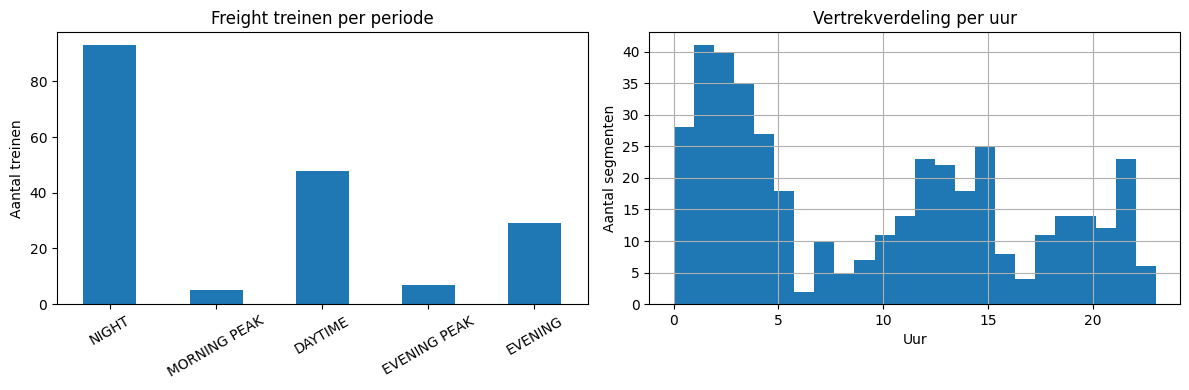

In [7]:
# Periodeverdeling van gegenereerde treinen
between = freight[freight['TYPE'] == 'BETWEEN-STATION'].copy()
between['HOUR'] = between['PLANNED_ENTRY'].dt.hour

def hour_to_period(h):
    if h < 6:   return 'NIGHT'
    if h < 9:   return 'MORNING PEAK'
    if h < 16:  return 'DAYTIME'
    if h < 19:  return 'EVENING PEAK'
    return 'EVENING'

between['PERIOD'] = between['HOUR'].apply(hour_to_period)
period_dist = between.groupby('PERIOD')['TRAIN_NO'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

period_order = ['NIGHT', 'MORNING PEAK', 'DAYTIME', 'EVENING PEAK', 'EVENING']
period_dist.reindex(period_order).plot(kind='bar', ax=axes[0])
axes[0].set_title('Freight treinen per periode')
axes[0].set_xlabel('')
axes[0].set_ylabel('Aantal treinen')
axes[0].tick_params(axis='x', rotation=30)

between['PLANNED_ENTRY'].dt.hour.hist(bins=24, ax=axes[1])
axes[1].set_title('Vertrekverdeling per uur')
axes[1].set_xlabel('Uur')
axes[1].set_ylabel('Aantal segmenten')

plt.tight_layout()
plt.show()

In [8]:
# Valideer rijtijden: freight moet ~1.3x passenger mediaan zijn
freight_rt = between.copy()
freight_rt['RUNNING_TIME_SEC'] = (
    freight_rt['PLANNED_EXIT'] - freight_rt['PLANNED_ENTRY']
).dt.total_seconds()

passenger_norm_check = normalize_to_base_date(passenger)
pass_between = passenger_norm_check[passenger_norm_check['SOURCE'] != passenger_norm_check['TARGET']].copy()
pass_between['PLANNED_ENTRY'] = pd.to_datetime(pass_between['PLANNED_ENTRY'])
pass_between['PLANNED_EXIT']  = pd.to_datetime(pass_between['PLANNED_EXIT'])
pass_between['RUNNING_TIME_SEC'] = (
    pass_between['PLANNED_EXIT'] - pass_between['PLANNED_ENTRY']
).dt.total_seconds()
pass_between = pass_between[pass_between['RUNNING_TIME_SEC'] > 0]

print("Rijtijdvergelijking per sectie (passenger mediaan vs freight):")
print(f"{'Sectie':<45} {'Passenger (s)':<15} {'Freight (s)':<15} {'Ratio':<8}")
print("-" * 85)

for (src, tgt), grp in freight_rt.groupby(['SOURCE', 'TARGET']):
    pass_grp = pass_between[
        (pass_between['SOURCE'] == src) & (pass_between['TARGET'] == tgt)
    ]
    if pass_grp.empty:
        continue
    pass_med    = pass_grp['RUNNING_TIME_SEC'].median()
    freight_med = grp['RUNNING_TIME_SEC'].median()
    ratio = freight_med / pass_med if pass_med > 0 else float('nan')
    sectie = f"{src} → {tgt}"
    print(f"{sectie:<45} {pass_med:<15.0f} {freight_med:<15.0f} {ratio:<8.2f}")

Rijtijdvergelijking per sectie (passenger mediaan vs freight):
Sectie                                        Passenger (s)   Freight (s)     Ratio   
-------------------------------------------------------------------------------------
ANDERLECHT → BRUSSEL-ZUID                     300             390             1.30    
BOCKSTAEL → BRUSSEL-NOORD                     300             390             1.30    
BOCKSTAEL → JETTE                             120             156             1.30    
BRUSSEL-NOORD → BOCKSTAEL                     240             312             1.30    
BRUSSEL-NOORD → SCHAARBEEK                    180             234             1.30    
BRUSSEL-WEST → BRUSSEL-ZUID                   300             390             1.30    
BRUSSEL-WEST → SIMONIS                        70              124             1.76    
BRUSSEL-ZUID → ANDERLECHT                     300             390             1.30    
BRUSSEL-ZUID → BRUSSEL-WEST                   300             390   

In [9]:
# Valideer één trein visueel
train_no = freight['TRAIN_NO'].iloc[0]
freight[freight['TRAIN_NO'] == train_no][
    ['TRAIN_NO', 'SOURCE', 'TARGET', 'SECTION',
     'TYPE', 'PLANNED_ENTRY', 'PLANNED_EXIT', 'RELATION_DIRECTION']
]

,TRAIN_NO,SOURCE,TARGET,SECTION,TYPE,PLANNED_ENTRY,PLANNED_EXIT,RELATION_DIRECTION
0,900000,BRUSSEL-ZUID,BRUSSEL-WEST,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,BETWEEN-STATION,2025-01-01 11:12:41.412106135,2025-01-01 11:19:11.412106135,T2b
1,900000,BRUSSEL-WEST,BRUSSEL-WEST,BRUSSEL-WEST,WITHIN-STATION-PASSING,2025-01-01 11:19:11.412106135,2025-01-01 11:19:12.412106135,T2b
2,900000,BRUSSEL-WEST,SIMONIS,28(1):BRUSSEL-WEST-SIMONIS,BETWEEN-STATION,2025-01-01 11:19:12.412106135,2025-01-01 11:21:48.412106135,T2b
3,900000,SIMONIS,SIMONIS,SIMONIS,WITHIN-STATION-PASSING,2025-01-01 11:21:48.412106135,2025-01-01 11:21:49.412106135,T2b
4,900000,SIMONIS,THURN EN TAXIS,28(1):SIMONIS-THURN EN TAXIS,BETWEEN-STATION,2025-01-01 11:21:49.412106135,2025-01-01 11:24:24.112106135,T2b
5,900000,THURN EN TAXIS,THURN EN TAXIS,THURN EN TAXIS,WITHIN-STATION-PASSING,2025-01-01 11:24:24.112106135,2025-01-01 11:24:25.112106135,T2b
6,900000,THURN EN TAXIS,SCHAARBEEK,28:THURN EN TAXIS-SCHAARBEEK,BETWEEN-STATION,2025-01-01 11:24:25.112106135,2025-01-01 11:31:18.512106135,T2b
7,900000,SCHAARBEEK,SCHAARBEEK,SCHAARBEEK,WITHIN-STATION-PASSING,2025-01-01 11:31:18.512106135,2025-01-01 11:31:19.512106135,T2b
8,900000,SCHAARBEEK,BRUSSEL-NOORD,36N:SCHAARBEEK-BRUSSEL-NOORD,BETWEEN-STATION,2025-01-01 11:31:19.512106135,2025-01-01 11:35:13.512106135,T2b


In [10]:
# Controleer SECTION formaat — moet consistent zijn met passenger
between_sections  = freight[freight['TYPE'] == 'BETWEEN-STATION']['SECTION'].unique()
passing_sections  = freight[freight['TYPE'] == 'WITHIN-STATION-PASSING']['SECTION'].unique()

print("Between-station secties (verwacht: {LINE}:{SRC}-{TGT}):")
for s in sorted(between_sections):
    print(f"  {s}")

print("\nPassing secties (verwacht: stationsnaam):")
for s in sorted(passing_sections):
    print(f"  {s}")

Between-station secties (verwacht: {LINE}:{SRC}-{TGT}):
  25:BRUSSEL-NOORD-SCHAARBEEK
  26:BRUSSEL-SCHUMAN-SCHAARBEEK
  26:SCHAARBEEK-BRUSSEL-SCHUMAN
  28(1):BRUSSEL-WEST-BRUSSEL-ZUID
  28(1):BRUSSEL-WEST-SIMONIS
  28(1):BRUSSEL-ZUID-BRUSSEL-WEST
  28(1):SIMONIS-BRUSSEL-WEST
  28(1):SIMONIS-THURN EN TAXIS
  28(1):THURN EN TAXIS-SIMONIS
  28:SCHAARBEEK-THURN EN TAXIS
  28:THURN EN TAXIS-SCHAARBEEK
  36N:SCHAARBEEK-BRUSSEL-NOORD
  50:BOCKSTAEL-BRUSSEL-NOORD
  50:BOCKSTAEL-JETTE
  50:BRUSSEL-NOORD-BOCKSTAEL
  50:JETTE-BOCKSTAEL
  50C:ANDERLECHT-BRUSSEL-ZUID
  50C:BRUSSEL-ZUID-ANDERLECHT
  60:JETTE-ZELLIK
  60:ZELLIK-JETTE

Passing secties (verwacht: stationsnaam):
  BOCKSTAEL
  BRUSSEL-WEST
  JETTE
  SCHAARBEEK
  SIMONIS
  THURN EN TAXIS


## 5. Sla op als gold

In [11]:
save_gold(freight, source='freight', n_trains=number_of_trains)

Opgeslagen (freight): 182 treinen, 654 segmenten → /Users/ddw/Desktop/Rescheduling/data/gold/freight/182
